In [51]:
%pip install wordcloud matplotlib pandas 

Note: you may need to restart the kernel to use updated packages.


In [52]:
import ast
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

%matplotlib inline
plt.rcParams['figure.dpi'] = 130

In [53]:
FILE_PATH = "/Users/kathleenwang/Documents/DS4200/music project/cleaned_music_data.csv"  # <- update if needed

df = pd.read_csv(FILE_PATH)
df.head()

,Major,School,Top Genre (#1),Top Genre (#2),Top Genre (#3),Top 3 Artists (please rank them),How many hours of music do you listen to per day on average (estimated)?,How many minutes of music did you listen to in 2025?,How many concerts did you attend in 2025?,"On average, how much did you spend on a concert ticket in 2025?",What is the maximum you would spend on a concert ticket?,What genres were the concerts you attended in 2025?,What is your favorite concert venue in Boston
0,Mechanical Engineering,College of Engineering,Hip-Hop,Indie,Jazz,"['kanye west', 'cosmos sheldrake', 'miles davis']",0.25,87,0,0,25.0,Hip-Hop,No preference
1,Political Science,College of Social Science and Humanities,R&B,Pop,Rock,"['daniel caesar', 'the 1975', 'yerin baek']",3,34000,3,150,200.0,"Pop, Rock",No preference
2,Computer Science,Khoury College of Computer Sciences,R&B,Pop,Indie,"['enhypen', 'dpr ian', 'silence wang']",6,18000,1,200,350.0,Pop,No preference
3,Economics,D'Amore-McKim School of Business,Electronic,Hip-Hop,Pop,"['gryffin', 'knock2', 'isoxo']",5,51943,5,90,500.0,Electronic,Roadrunner
4,Finance,D'Amore-McKim School of Business,Pop,R&B,Indie,"['lana del rey', 'ariana grande', 'sabrina car...",0.6,36000,5,200,600.0,"Pop, R&B, Country, Electronic",Roadrunner


In [54]:
df.columns = [
    "major", "college",
    "genre1", "genre2", "genre3",
    "top_artists",
    "hours_per_day", "minutes_2025",
    "concerts_attended", "avg_ticket_spend",
    "max_ticket", "concert_genres", "fav_venue"
]

print(f"Loaded {len(df)} responses across {df['college'].nunique()} colleges.")
df.head(3)

Loaded 101 responses across 7 colleges.


,major,college,genre1,genre2,genre3,top_artists,hours_per_day,minutes_2025,concerts_attended,avg_ticket_spend,max_ticket,concert_genres,fav_venue
0,Mechanical Engineering,College of Engineering,Hip-Hop,Indie,Jazz,"['kanye west', 'cosmos sheldrake', 'miles davis']",0.25,87,0,0,25.0,Hip-Hop,No preference
1,Political Science,College of Social Science and Humanities,R&B,Pop,Rock,"['daniel caesar', 'the 1975', 'yerin baek']",3,34000,3,150,200.0,"Pop, Rock",No preference
2,Computer Science,Khoury College of Computer Sciences,R&B,Pop,Indie,"['enhypen', 'dpr ian', 'silence wang']",6,18000,1,200,350.0,Pop,No preference


In [55]:
def clean_genre(g):
    """Normalise a genre string: strip whitespace, title-case, merge aliases."""
    if not isinstance(g, str):
        return None
    g = g.strip().title()
    aliases = {
        "Hip-Hop": ["Hip Hop", "Hiphop", "Hip-Hop"],
        "R&B":     ["R&Amp;B", "Rnb", "R And B"],
        "K-Pop":   ["Kpop", "K Pop", "K-Pop"],
        "Electronic": ["Edm", "Electronic Dance"],
    }
    for canonical, variants in aliases.items():
        if g in variants:
            return canonical
    return g


def parse_artists(raw):
    """Parse an artist list string into a Python list of title-cased names."""
    if not isinstance(raw, str):
        return []
    try:
        artists = ast.literal_eval(raw)
        return [a.strip().title() for a in artists if isinstance(a, str) and a.strip()]
    except Exception:
        raw = re.sub(r"[\[\]'\"]", "", raw)
        return [a.strip().title() for a in raw.split(",") if a.strip()]


# Genre frequency dicts
top1_genres = dict(
    Counter(clean_genre(g) for g in df["genre1"] if clean_genre(g))
)

all_top3_genres = dict(
    Counter(
        clean_genre(g)
        for col in ["genre1", "genre2", "genre3"]
        for g in df[col]
        if clean_genre(g)
    )
)

concert_genre_counts = Counter()
for entry in df["concert_genres"].dropna():
    for g in str(entry).split(","):
        g = clean_genre(g)
        if g and g.lower() not in ("none", "n/a", "na"):
            concert_genre_counts[g] += 1
concert_genres = dict(concert_genre_counts)

# Artist frequency dicts
all_artists = dict(
    Counter(
        artist
        for raw in df["top_artists"]
        for artist in parse_artists(raw)
    )
)

# Per-college breakdowns
college_genres = {}
college_artists = {}

for college, group in df.groupby("college"):
    college_genres[college] = dict(
        Counter(
            clean_genre(g)
            for col in ["genre1", "genre2", "genre3"]
            for g in group[col]
            if clean_genre(g)
        )
    )
    college_artists[college] = dict(
        Counter(
            artist
            for raw in group["top_artists"]
            for artist in parse_artists(raw)
        )
    )

print("Top genres (all top-3):", sorted(all_top3_genres.items(), key=lambda x: -x[1])[:8])
print("\nTop artists overall:",   sorted(all_artists.items(),     key=lambda x: -x[1])[:8])

Top genres (all top-3): [('R&B', 59), ('Pop', 58), ('Indie', 39), ('Hip-Hop', 33), ('Electronic', 28), ('Rap', 25), ('Rock', 17), ('K-Pop', 13)]

Top artists overall: [('Daniel Caesar', 8), ('Sza', 7), ('Drake', 7), ('Don Toliver', 7), ('Knock2', 6), ('Keshi', 5), ('Olivia Dean', 5), ('Tyler The Creator', 4)]


## 4. Helper functions

In [56]:
COLLEGE_COLORS = {
    "Khoury College of Computer Sciences":       "#7F77DD",
    "D'Amore-McKim School of Business":          "#1D9E75",
    "College of Engineering":                    "#EF9F27",
    "College of Science":                        "#D85A30",
    "Bouve College of Health Sciences":          "#378ADD",
    "College of Social Science and Humanities":  "#639922",
    "College of Arts, Media, and Design":        "#D4537E",
}

def make_single_color_func(hex_color):
    """WordCloud color_func that shades words in a single hue by font size."""
    r, g, b = int(hex_color[1:3], 16), int(hex_color[3:5], 16), int(hex_color[5:7], 16)

    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        factor = min(0.4 + 0.6 * (font_size / 80), 1.0)
        return f"rgb({int(r*factor)},{int(g*factor)},{int(b*factor)})"

    return color_func

def build_wc(freq_dict, colormap=None, color_func=None,
             max_words=60, width=800, height=420):
    """Build and return a WordCloud from a frequency dictionary."""
    wc = WordCloud(
        width=width,
        height=height,
        background_color="white",
        max_words=max_words,
        prefer_horizontal=0.85,
        colormap=colormap,
        color_func=color_func,
        relative_scaling=0.55,
        min_font_size=12,
    )
    wc.generate_from_frequencies(freq_dict)
    return wc

def cloud_grid(data_dict, title, filename, ncols=3, max_words=40):
    """Render a grid of word clouds, one per key in data_dict."""
    items = [(k, v) for k, v in data_dict.items() if v]
    nrows = (len(items) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5.5))
    fig.suptitle(title, fontsize=30, fontweight="bold", y=1.01)
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else axes

    for i, (label, freq) in enumerate(items):
        ax = axes_flat[i]
        hex_col = COLLEGE_COLORS.get(label, "#888888")
        wc = build_wc(freq, color_func=make_single_color_func(hex_col), max_words=max_words)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(label, fontsize=21, fontweight="500", pad=8)

    for j in range(len(items), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {filename}")

## 5. Overall genre clouds
Three side-by-side clouds: top-ranked genre, all top-3 picks, and concert genres.

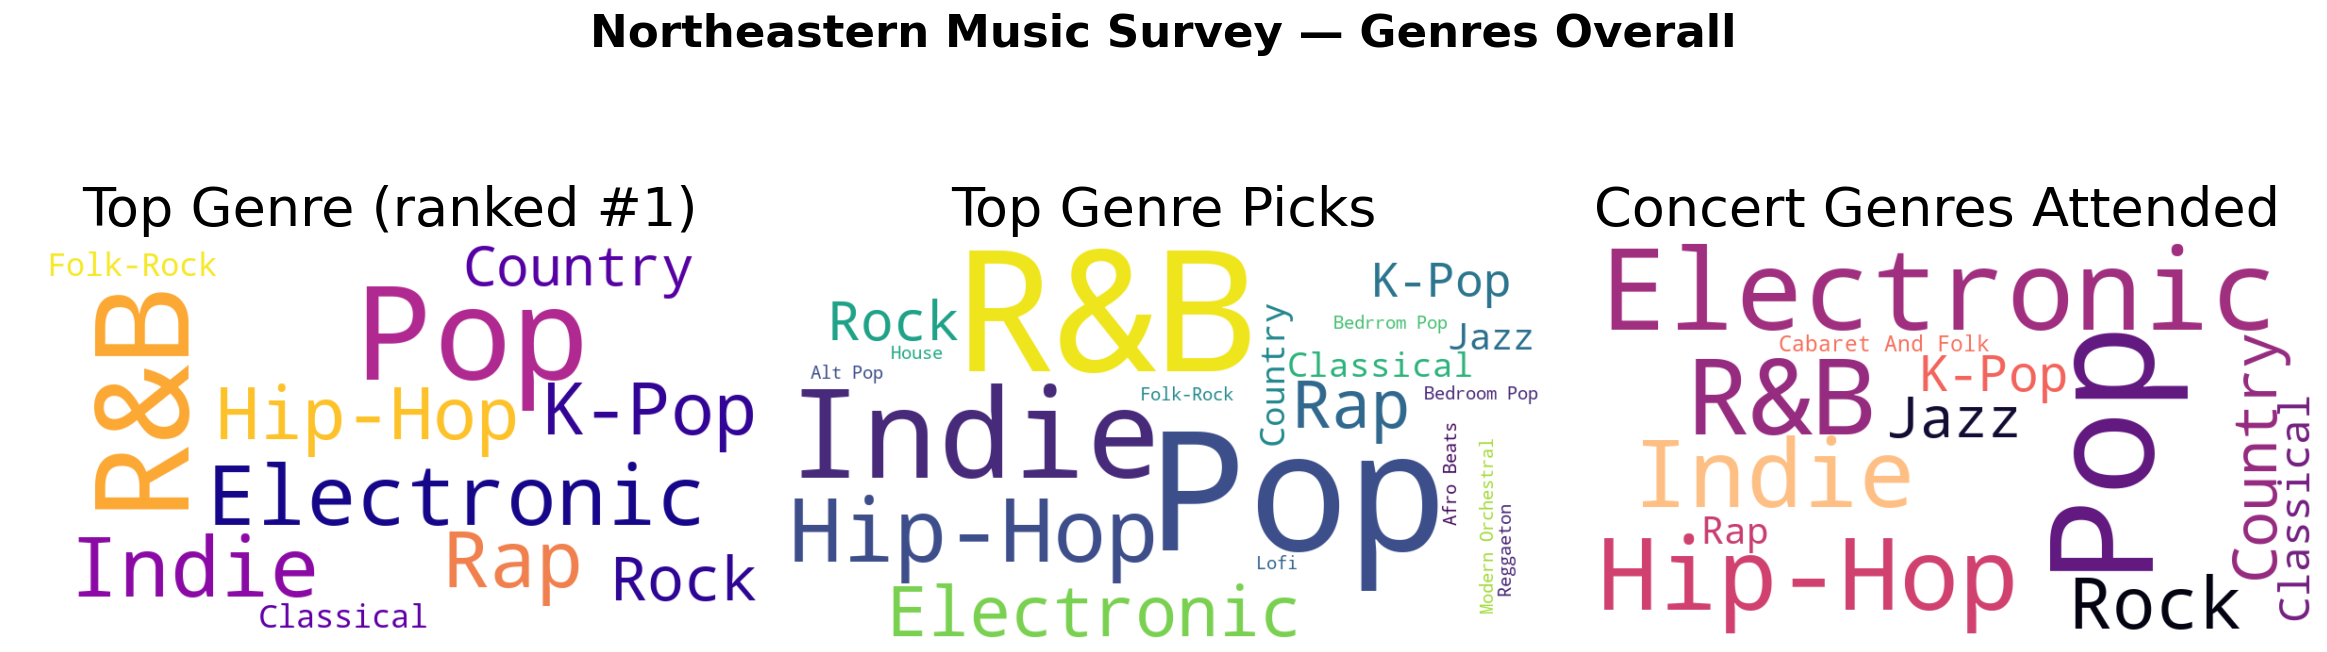

Saved -> genres_overall.png


In [57]:
overall_data = [
    ("Top Genre (ranked #1)", top1_genres,    "plasma"),
    ("Top Genre Picks",    all_top3_genres, "viridis"),
    ("Concert Genres Attended",  concert_genres,  "magma"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Northeastern Music Survey — Genres Overall",
             fontsize=25, fontweight="bold", y=1.01)

for ax, (title, data, cmap) in zip(axes, overall_data):
    wc = build_wc(data, colormap=cmap)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=30, fontweight="500", pad=10)

plt.tight_layout()
plt.savefig("genres_overall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> genres_overall.png")

## 6. Genre clouds by college

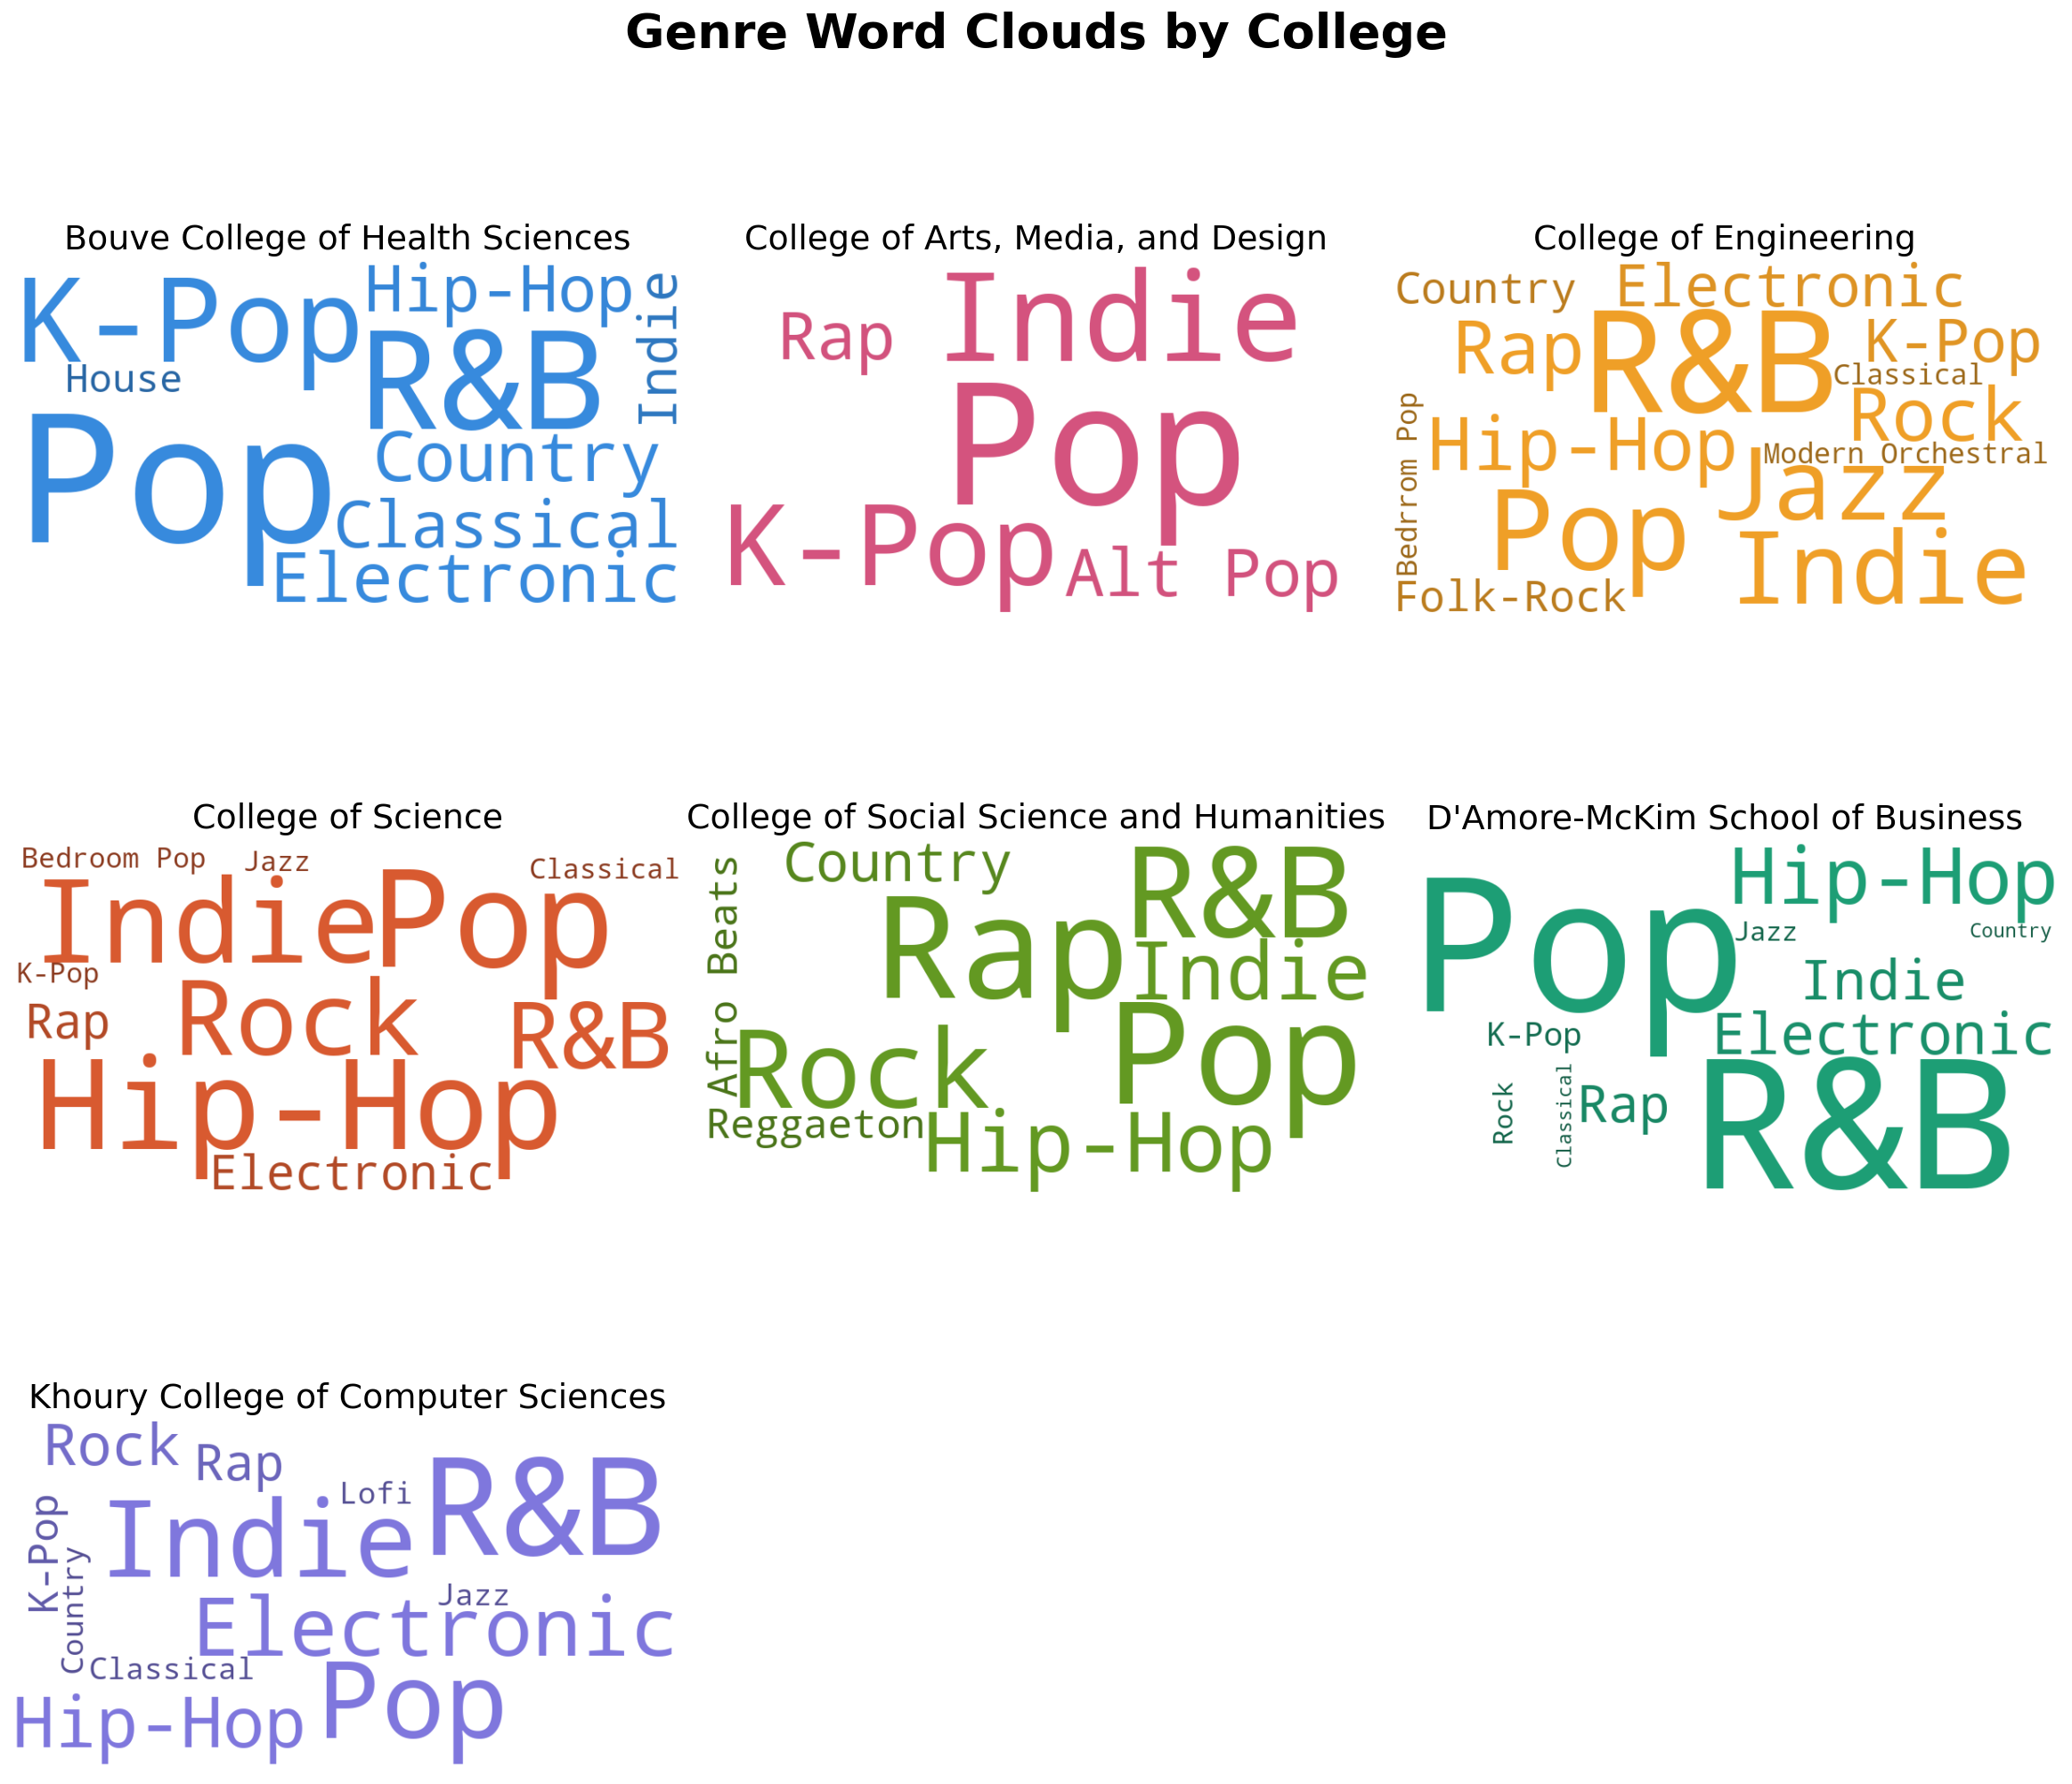

Saved -> genre_by_college.png


In [58]:
cloud_grid(
    data_dict=college_genres,
    title="Genre Word Clouds by College",
    filename="genre_by_college.png",
    max_words=40,
)

## 7. Overall artist cloud
All artists mentioned across every student's top-3 picks, sized by number of mentions.

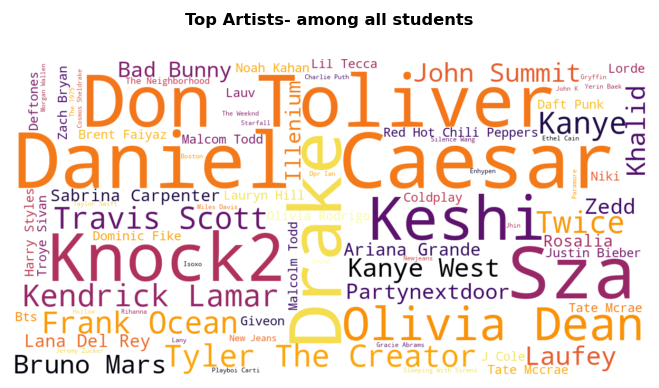

Saved -> artists_overall.png


In [68]:
fig, ax = plt.subplots(figsize=(19, 3))
fig.suptitle("Top Artists- among all students",
             fontsize=9, fontweight="bold")

wc = build_wc(all_artists, colormap="inferno", max_words=80, width=1200, height=600)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")

plt.tight_layout()
plt.savefig("artists_overall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> artists_overall.png")

## 8. Artist clouds by college

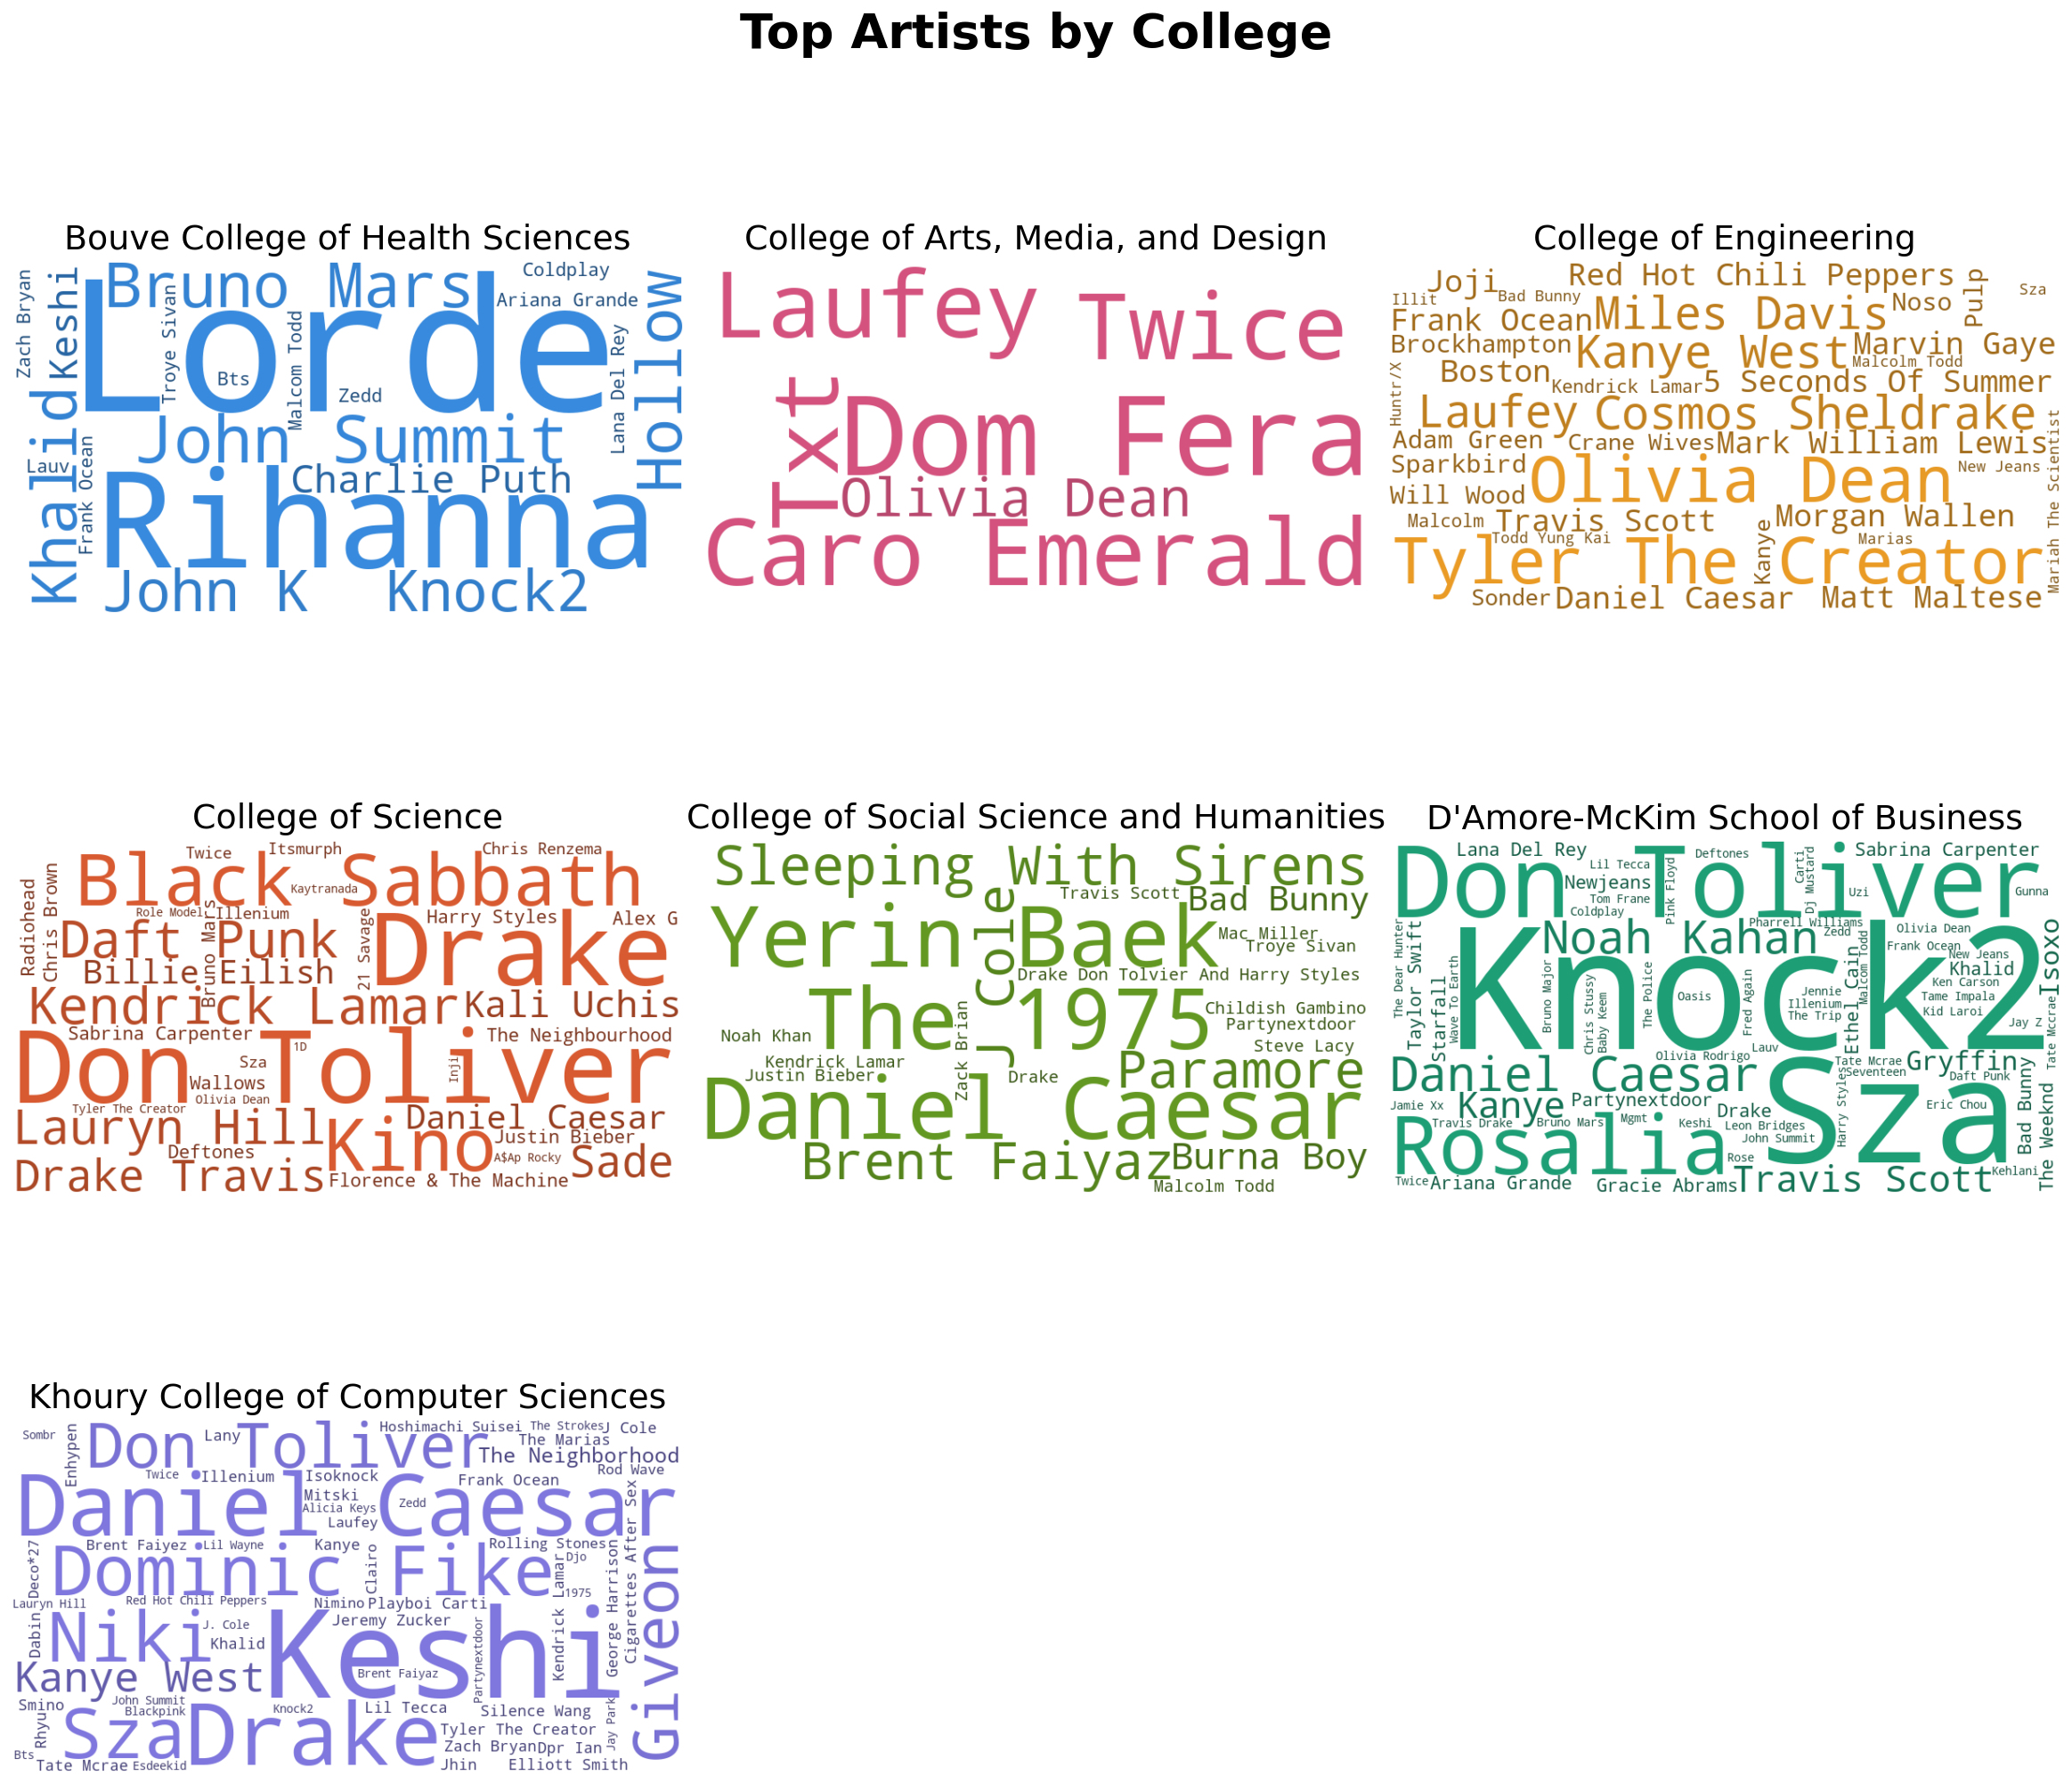

Saved -> artist_by_college.png


In [60]:
cloud_grid(
    data_dict=college_artists,
    title="Top Artists by College",
    filename="artist_by_college.png",
    max_words=100,
)